# DATA266 Lab 1 — Task 2: Yelp Polarity Sentiment Classification (Dipin)

Three models, all with **word embeddings learned from scratch** (no pretrained embeddings or LMs):

| Model | Architecture | What changes vs previous |
|---|---|---|
| Baseline | Embedding(200) → 1-layer LSTM(128) → last hidden state → linear | — |
| Experimental 1 | Embedding(200) → 2-layer **BiLSTM**(128) → concat final fwd/bwd → linear | direction + depth |
| Experimental 2 | Embedding(200) → 2-layer BiLSTM(128) → **additive attention pooling** → linear | pooling only |

Split/test protocol is shared with Khushi (stratified 90/10 of the official train pool, seed 42; official 38k test set untouched), so the team comparison is on identical data.
All hyperparameters live in `configs/task2_config.json`.

Set the environment variable `DIPIN_T2_SMOKE=1` to run this notebook on a tiny subset (pipeline check only).

In [1]:
import json, os, platform, subprocess, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Locate this member's task folder without any hard-coded personal path.
TASK_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs" / "task2_config.json").exists())
sys.path.insert(0, str(TASK_DIR / "src"))

from data_prep import audit_raw, load_config, load_raw, prepare_all, set_seed, Preprocessor
from models import count_parameters
from train import get_device, hardware_info, load_model, make_loader, predict, train_model
import evaluate as ev

SMOKE = os.environ.get("DIPIN_T2_SMOKE") == "1"
cfg = load_config()
set_seed(cfg["seed"])
OUT = TASK_DIR / "outputs" / ("smoke" if SMOKE else "")  # smoke runs never touch real outputs
for sub in ["eda", "plots", "predictions", "error_review"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)
device = get_device()
HW = hardware_info(device)
print("task dir:", TASK_DIR.name, "| smoke:", SMOKE)
print(json.dumps(HW, indent=2))

task dir: dipin | smoke: False
{
  "device": "cuda",
  "cpu": "Intel(R) Core(TM) Ultra 9 285K",
  "platform": "Windows-11-10.0.26200-SP0",
  "python": "3.12.10",
  "torch": "2.11.0+cu128",
  "gpu": "NVIDIA GeForce RTX 5090",
  "gpu_memory_gb": 34.19,
  "cuda": "12.8",
  "cudnn": 91900
}


## 2.1 Data preprocessing
### Load raw data, audit for missing / malformed entries

In [2]:
train_text, train_y, test_text, test_y = load_raw(cfg["dataset"])
audit = {"train": audit_raw(train_text, train_y), "test": audit_raw(test_text, test_y)}
pd.DataFrame(audit)

,train,test
n,560000,38000
missing,0,0
empty_or_whitespace,0,0
bad_labels,0,0
literal_escape_sequences,269718,18279
html_tags,0,0
non_ascii,0,0
exact_duplicate_texts,0,0


**Findings.** There are no missing texts, empty reviews, invalid labels or HTML tags. The only malformed content is *literal* escape sequences: about half of all reviews contain `\n` stored as two characters rather than a newline.
Left alone, punctuation stripping would turn `\n` into a stray `n` token, so the cleaner replaces these sequences with spaces first.
A few reviews become empty after cleaning (see the preprocessing table below). They are kept, not dropped, so the split stays identical to the team's, and the model handles them as length-0 inputs.

,train,test,train_%,test_%
negative (0),280000,19000,50.0,50.0
positive (1),280000,19000,50.0,50.0


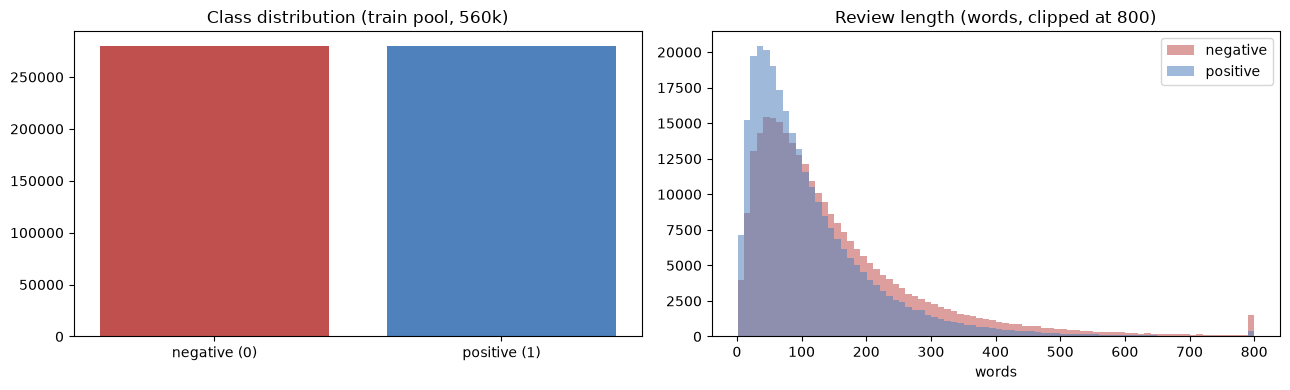

,count,mean,std,min,50%,90%,95%,99%,max
negative,280000.0,151.5,135.7,1.0,112.0,319.0,419.0,681.0,1052.0
positive,280000.0,114.5,104.8,1.0,84.0,241.0,316.0,512.0,998.0


In [3]:
counts = pd.DataFrame({"train": pd.Series(train_y).value_counts().sort_index(),
                       "test": pd.Series(test_y).value_counts().sort_index()})
counts.index = ["negative (0)", "positive (1)"]
counts["train_%"] = 100 * counts["train"] / counts["train"].sum()
counts["test_%"] = 100 * counts["test"] / counts["test"].sum()
display(counts)

wc_train = np.array([len(t.split()) for t in train_text])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts.index, counts["train"], color=["#c0504d", "#4f81bd"])
axes[0].set_title("Class distribution (train pool, 560k)")
for lab, name, c in [(0, "negative", "#c0504d"), (1, "positive", "#4f81bd")]:
    axes[1].hist(np.clip(wc_train[train_y == lab], 0, 800), bins=80, alpha=0.55, label=name, color=c)
axes[1].set_title("Review length (words, clipped at 800)"); axes[1].set_xlabel("words"); axes[1].legend()
fig.tight_layout(); fig.savefig(OUT / "eda" / "class_and_length_distribution.png", dpi=120); plt.show()

length_stats = pd.DataFrame({name: pd.Series(wc_train[train_y == lab]).describe(percentiles=[.5, .9, .95, .99])
                             for lab, name in [(0, "negative"), (1, "positive")]}).T
display(length_stats.round(1))

The classes are perfectly balanced (50/50 in both train and test), so no class weighting or resampling is needed, and accuracy is a meaningful headline metric.
Review lengths are heavily right-skewed. Negative reviews tend to be longer than positive ones (see table), so length is a weak confounder. That is why length slices are part of the robustness evaluation.

### Text preprocessing → tokenization → vocabulary → integer sequences
Pipeline: unescape literal `\n`, lowercase, expand negation contractions (`didn't` → `did not`), remove punctuation and special characters, whitespace-tokenize,
remove NLTK English stopwords **except negations** (`not`, `no`, `never`, … flip sentiment), then apply **WordNet lemmatization** (noun pass, then verb pass: `loved` → `love`, `places` → `place`).
Lemmatization rather than stemming keeps real words, so the learned embeddings and the error review stay interpretable.

In [4]:
pre = Preprocessor(cfg["preprocessing"])
for t in [train_text[0], train_text[3]]:
    print("RAW :", t[:300].replace("\\n", " "))
    print("PROC:", " ".join(pre(t))[:300]); print()

t0 = time.time()
data = prepare_all(cfg, max_train=4000, out_dir=OUT / "data") if SMOKE else prepare_all(cfg)
print(f"preprocessing took {time.time() - t0:.0f}s")
meta = data["meta"]
vocab_size = len(data["stoi"])
display(pd.DataFrame(meta["splits"]).T)
print("vocab size (incl. <PAD>, <UNK>):", vocab_size, "| unique train tokens:", meta["train_unique_tokens"],
      "| train/val overlap:", meta["train_validation_overlap"])

RAW : Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has ti


PROC: unfortunately frustration dr goldberg patient repeat experience many doctor nyc good doctor terrible staff seem staff simply never answer phone usually take 2 hour repeat call get answer time want deal run problem many doctor not get office worker patient medical need not anyone answer phone incompr

RAW : I'm writing this review to give you a heads up before you see this Doctor. The office staff and administration are very unprofessional. I left a message with multiple people regarding my bill, and no one ever called me back. I had to hound them to get an answer about my bill.   Second, and most im
PROC: write review give head see doctor office staff administration unprofessional leave message multiple people regard bill no one ever call back hound get answer bill second important make sure insurance go cover dr goldberg visit blood work recommend get physical know student tell get physical do later



preprocessed train: 504000 reviews


preprocessed validation: 56000 reviews


preprocessed test: 38000 reviews


preprocessing took 52s


,n,label0,label1,empty_after_cleaning,truncated,truncated_pct,processed_length_percentiles_50_90_95_99,unk_rate_pct
train,504000,252000,252000,24,22896,4.542857,"[51.0, 147.0, 193.0, 317.0]",0.642083
validation,56000,28000,28000,8,2515,4.491071,"[51.0, 146.0, 193.0, 314.0]",0.737099
test,38000,19000,19000,0,1694,4.457895,"[51.0, 146.0, 192.0, 312.0]",0.699589


vocab size (incl. <PAD>, <UNK>): 40002 | unique train tokens: 174508 | train/val overlap: 0


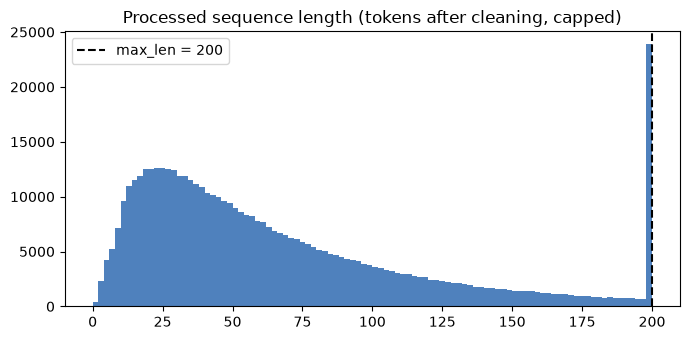

processed length p50/p90/p95/p99: [ 51. 147. 193. 317.] | truncated: 4.54% of train


In [5]:
proc_len = data["lengths"]["train"]
fig, ax = plt.subplots(figsize=(7, 3.5))
lens_all = np.array(meta["splits"]["train"]["processed_length_percentiles_50_90_95_99"])
ax.hist(np.minimum(proc_len, cfg["preprocessing"]["max_sequence_length"]), bins=100, color="#4f81bd")
ax.axvline(cfg["preprocessing"]["max_sequence_length"], color="k", ls="--", label="max_len = 200")
ax.set_title("Processed sequence length (tokens after cleaning, capped)"); ax.legend()
fig.tight_layout(); fig.savefig(OUT / "eda" / "processed_length.png", dpi=120); plt.show()
print("processed length p50/p90/p95/p99:", lens_all,
      f"| truncated: {meta['splits']['train']['truncated_pct']:.2f}% of train")

`max_len = 200` covers about 96% of reviews without truncation, and keeps LSTM compute bounded.
For the ~4% that are longer, the encoder keeps the first 150 and the **last 50** tokens (head+tail), because Yelp reviews often end with the overall verdict.
The vocabulary is built on the **training split only**: tokens with frequency ≥ 3, capped at 40k. Everything else maps to `<UNK>`, and `<PAD>`=0 is masked out of the LSTM via packing.

### Embeddings learned from scratch
Each model owns an `nn.Embedding(vocab_size, 200, padding_idx=0)`, initialized uniformly in [-0.05, 0.05] and trained jointly with the classifier.
Nothing pretrained is loaded. Section 2.2 ends with a nearest-neighbour check showing the embeddings learned sentiment structure.

## 2.2 Model training
All three share: AdamW (lr 2e-3, wd 1e-4), batch 256, linear warm-up (5%) then cosine decay, gradient clipping at 1.0, BCE-with-logits loss on one logit,
up to 4 epochs with early stopping on validation macro-F1 (patience 2). The checkpoint with the best validation macro-F1 is kept.

[baseline] params=8,169,489 device=NVIDIA GeForce RTX 5090 run_id=task2_baseline_20260925_163551


[baseline] epoch 1: train_loss=0.2143 val_loss=0.1462 val_acc=0.9437 val_f1=0.9437 (42s, 11990 ex/s)


[baseline] epoch 2: train_loss=0.1216 val_loss=0.1483 val_acc=0.9444 val_f1=0.9444 (42s, 12021 ex/s)


[baseline] epoch 3: train_loss=0.0883 val_loss=0.1406 val_acc=0.9492 val_f1=0.9492 (41s, 12150 ex/s)


[baseline] epoch 4: train_loss=0.0654 val_loss=0.1521 val_acc=0.9484 val_f1=0.9484 (42s, 12024 ex/s)
[experimental_1] params=8,733,841 device=NVIDIA GeForce RTX 5090 run_id=task2_experimental_1_20260925_163845


...

[experimental_2] params=8,766,865 device=NVIDIA GeForce RTX 5090 run_id=task2_experimental_2_20260925_164755


[experimental_2] epoch 1: train_loss=0.1912 val_loss=0.1378 val_acc=0.9462 val_f1=0.9462 (176s, 2871 ex/s)


[experimental_2] epoch 2: train_loss=0.1116 val_loss=0.1320 val_acc=0.9490 val_f1=0.9490 (173s, 2912 ex/s)


[experimental_2] epoch 3: train_loss=0.0797 val_loss=0.1345 val_acc=0.9508 val_f1=0.9508 (172s, 2926 ex/s)


[experimental_2] epoch 4: train_loss=0.0557 val_loss=0.1542 val_acc=0.9495 val_f1=0.9495 (172s, 2923 ex/s)


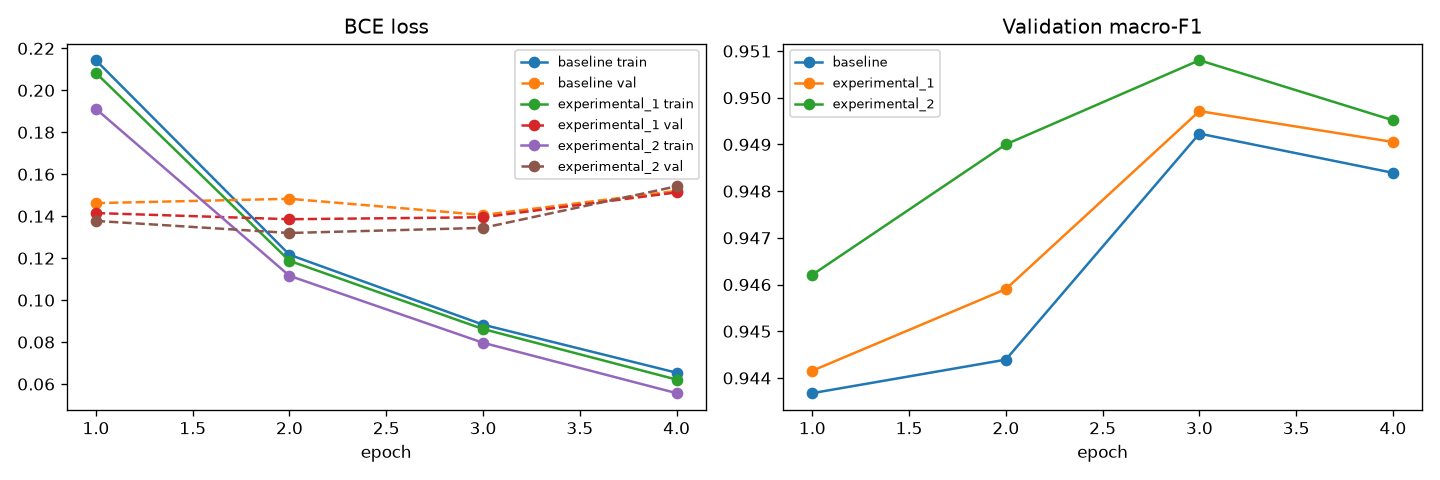

In [6]:
summaries, ckpts = {}, {}
for name in cfg["models"]:
    summaries[name], ckpts[name] = train_model(name, cfg, data, vocab_size, device,
                                               epochs=1 if SMOKE else None, tag="_smoke" if SMOKE else "")
ev.plot_history(summaries, OUT / "plots" / "training_curves.png")
from IPython.display import Image
Image(filename=str(OUT / "plots" / "training_curves.png"))

In [7]:
eff = pd.DataFrame({n: {"parameters": s["parameter_count"], "best_epoch": s["best_epoch"], "epochs_run": s["epochs_run"],
                        "train_time_s": round(s["training_seconds"], 1),
                        "train_examples_per_sec": round(s["train_examples_per_sec"], 1),
                        "peak_gpu_mem_MB": None if s["peak_accelerator_bytes"] is None else round(s["peak_accelerator_bytes"] / 2**20, 1),
                        "peak_host_rss_MB": round(s["peak_host_rss_bytes"] / 2**20, 1),
                        "gpu": s["hardware"].get("gpu"), "cpu": s["hardware"]["cpu"],
                        "checkpoint": s["checkpoint"], "raw_log": s["raw_log"]} for n, s in summaries.items()}).T
eff

,parameters,best_epoch,epochs_run,train_time_s,train_examples_per_sec,peak_gpu_mem_MB,peak_host_rss_MB,gpu,cpu,checkpoint,raw_log
baseline,8169489,3,4,167.4,12046.0,577.1,3752.5,NVIDIA GeForce RTX 5090,Intel(R) Core(TM) Ultra 9 285K,task2_sentiment\dipin\checkpoints\baseline.pt,reproducibility\raw_logs\dipin\task2_baseline_...
experimental_1,8733841,3,4,543.1,3711.9,978.8,3771.7,NVIDIA GeForce RTX 5090,Intel(R) Core(TM) Ultra 9 285K,task2_sentiment\dipin\checkpoints\experimental...,reproducibility\raw_logs\dipin\task2_experimen...
experimental_2,8766865,3,4,693.3,2907.9,980.3,3877.3,NVIDIA GeForce RTX 5090,Intel(R) Core(TM) Ultra 9 285K,task2_sentiment\dipin\checkpoints\experimental...,reproducibility\raw_logs\dipin\task2_experimen...


## Evaluation on the official 38,000-review test set

In [8]:
test_loader = make_loader(data["ids"]["test"], data["lengths"]["test"], data["labels"]["test"], 1024, False, cfg["seed"])
slices = ev.build_slices(data["raw_text"]["test"], data["unks"]["test"], data["lengths"]["test"], data["truncated"]["test"])
metrics, preds, probs, per_slice = {}, {}, {}, {}
for name, path in ckpts.items():
    model, _ = load_model(path, device)
    t0 = time.perf_counter()
    y_test, probs[name] = predict(model, test_loader, device)
    infer_s = time.perf_counter() - t0
    metrics[name], preds[name] = ev.compute_metrics(y_test, probs[name], cfg)
    metrics[name].update(parameter_count=summaries[name]["parameter_count"],
                         training_time_s=summaries[name]["training_seconds"],
                         train_examples_per_sec=summaries[name]["train_examples_per_sec"],
                         inference_examples_per_sec=len(y_test) / infer_s,
                         peak_gpu_memory_bytes=summaries[name]["peak_accelerator_bytes"],
                         peak_host_rss_bytes=summaries[name]["peak_host_rss_bytes"])
    per_slice[name] = ev.slice_metrics(y_test, preds[name], slices)
    ev.plot_confusion(y_test, preds[name], name, OUT / "plots" / f"confusion_{name}.png")
    pd.DataFrame({"test_index": np.arange(len(y_test)), "true_label": y_test, "predicted_label": preds[name],
                  "prob_positive": probs[name]}).to_csv(OUT / "predictions" / f"{name}_test_predictions.csv", index=False)

metrics_df = pd.DataFrame(metrics)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
metrics_df

,baseline,experimental_1,experimental_2
accuracy,0.9518,0.9531,0.9533
precision_macro,0.9518,0.9531,0.9533
recall_macro,0.9518,0.9531,0.9533
f1_macro,0.9518,0.9531,0.9533
precision_micro,0.9518,0.9531,0.9533
recall_micro,0.9518,0.9531,0.9533
f1_micro,0.9518,0.9531,0.9533
precision_weighted,0.9518,0.9531,0.9533
recall_weighted,0.9518,0.9531,0.9533
f1_weighted,0.9518,0.9531,0.9533


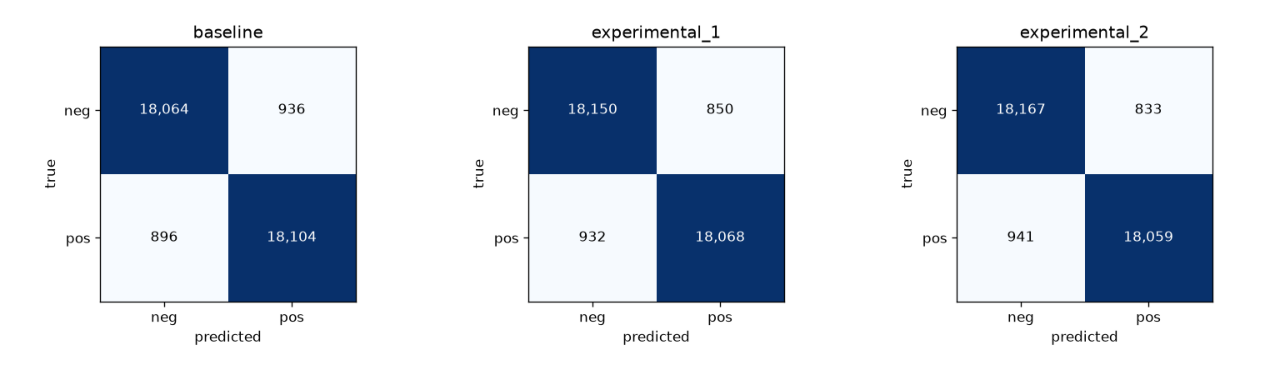

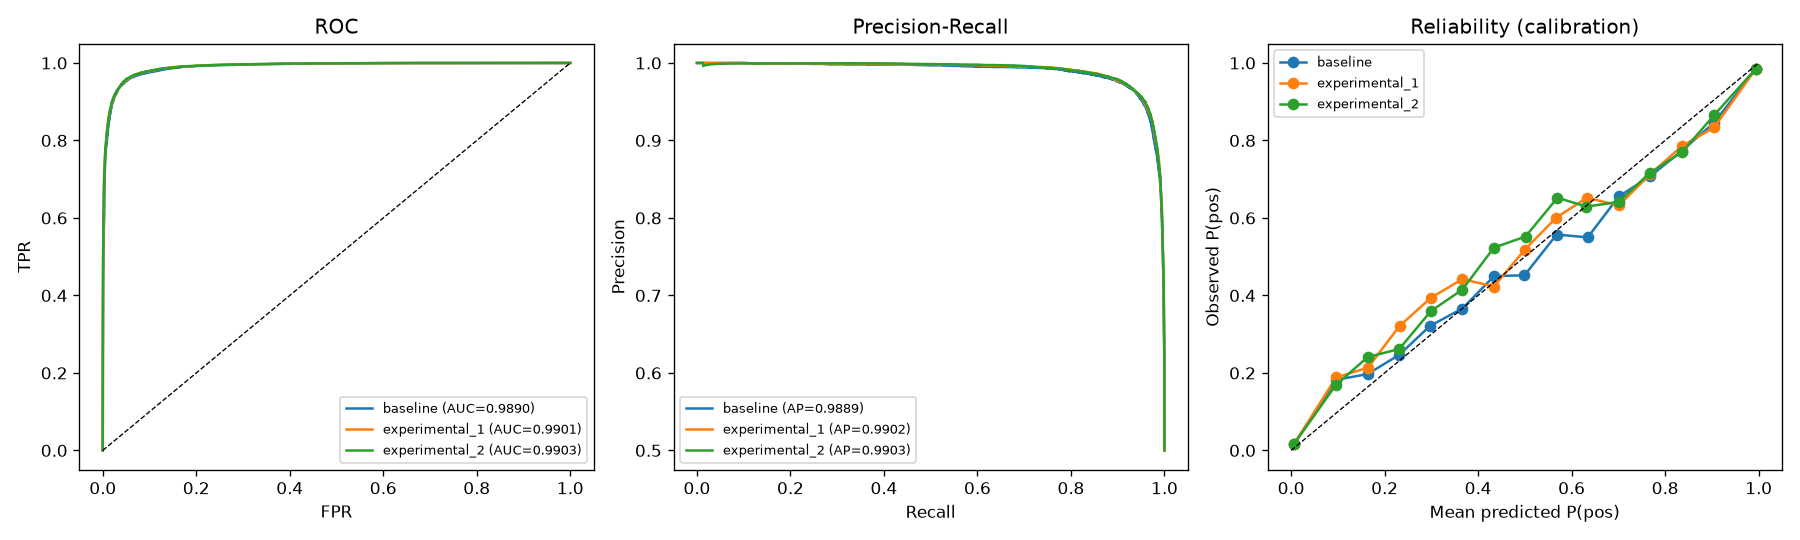

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, name in zip(axes, ckpts):
    ax.imshow(plt.imread(OUT / "plots" / f"confusion_{name}.png")); ax.axis("off")
fig.tight_layout(); plt.show()
ev.plot_curves(probs, y_test, OUT / "plots" / "roc_pr_calibration.png")
Image(filename=str(OUT / "plots" / "roc_pr_calibration.png"))

### 95% bootstrap confidence intervals (1,000 resamples) and paired McNemar tests

In [10]:
ci = pd.DataFrame({n: {f"{k}": f"{m[k if k != 'macro_f1' else 'f1_macro']:.4f} [{m[k + '_ci95_lower']:.4f}, {m[k + '_ci95_upper']:.4f}]"
                       for k in ["accuracy", "macro_f1", "mcc"]} for n, m in metrics.items()}).T
display(ci)
mc = {f"baseline vs {n}": ev.mcnemar(y_test, preds["baseline"], preds[n]) for n in ["experimental_1", "experimental_2"]}
mc["experimental_1 vs experimental_2"] = ev.mcnemar(y_test, preds["experimental_1"], preds["experimental_2"])
mcnemar_df = pd.DataFrame(mc).T
mcnemar_df

,accuracy,macro_f1,mcc
baseline,"0.9518 [0.9496, 0.9539]","0.9518 [0.9496, 0.9539]","0.9036 [0.8993, 0.9078]"
experimental_1,"0.9531 [0.9511, 0.9551]","0.9531 [0.9511, 0.9551]","0.9062 [0.9021, 0.9102]"
experimental_2,"0.9533 [0.9512, 0.9554]","0.9533 [0.9512, 0.9554]","0.9066 [0.9023, 0.9108]"


,a_right_b_wrong,a_wrong_b_right,p_value
baseline vs experimental_1,373.0000,423.0000,0.0824
baseline vs experimental_2,430.0000,488.0000,0.0599
experimental_1 vs experimental_2,431.0000,439.0000,0.8124


### Robustness: macro-F1 and error rate per data slice

In [11]:
slice_rows = []
for name, sl in per_slice.items():
    for s, v in sl.items():
        slice_rows.append({"model": name, "slice": s, **v})
slice_df = pd.DataFrame(slice_rows)
display(slice_df.pivot(index="slice", columns="model", values="macro_f1").join(
        slice_df.pivot(index="slice", columns="model", values="error_rate"), lsuffix="_macroF1", rsuffix="_errRate")
        .join(slice_df[slice_df.model == "baseline"].set_index("slice")["n"]))

,baseline_macroF1,experimental_1_macroF1,experimental_2_macroF1,baseline_errRate,experimental_1_errRate,experimental_2_errRate,n
slice,,,,,,,
all,0.9518,0.9531,0.9533,0.0482,0.0469,0.0467,38000
contains_contrast_word,0.9467,0.9484,0.9483,0.0528,0.0511,0.0512,22551
contains_negation,0.9494,0.9506,0.9515,0.0491,0.0479,0.0470,28526
high_unk_rate(>10%),0.8442,0.8421,0.8333,0.1385,0.1385,0.1472,231
raw_length_long(> 142 words),0.9507,0.9523,0.9524,0.0478,0.0461,0.0460,12575
raw_length_medium(65-142),0.9529,0.9534,0.9553,0.0471,0.0466,0.0447,12649
raw_length_short(<= 65 words),0.9488,0.9506,0.9492,0.0497,0.0480,0.0493,12776
truncated,0.9303,0.9361,0.9250,0.0614,0.0561,0.0661,1694


### Sanity check: did the from-scratch embeddings learn sentiment?
Cosine nearest neighbours in the embedding table of the best model.

In [12]:
best = max(summaries, key=lambda n: summaries[n]["best_val_macro_f1"])
print("best model by validation macro-F1:", best)
model, _ = load_model(ckpts[best], device)
E = torch.nn.functional.normalize(model.embedding.weight.detach().float().cpu(), dim=1)
itos = list(data["stoi"])
for w in ["great", "terrible", "delicious", "rude", "never", "recommend"]:
    if w in data["stoi"]:
        sims = E @ E[data["stoi"][w]]
        nn_ids = sims.topk(9).indices[1:].tolist()
        print(f"{w:>10}: {', '.join(itos[i] for i in nn_ids)}")

best model by validation macro-F1: experimental_2
     great: cuddly, likey, cheerful, outstanding, devient, yun, yummm, delightful
  terrible: horrible, scamming, hyena, overt, aweful, franzia, 866, ballad
 delicious: drawback, fantastic, phenomenal, tartine, raptor, blick, yay, perfection
      rude: belittle, tasteless, supposably, stale, unappetizing, abusive, u00e9diocre, letdown
     never: nie, cant, not, wont, no, etiquette, nor, avoid
 recommend: precise, aftercare, unwind, starlight, unpretentious, prost, attentionn, tish


## Error review candidates (20 errors from the best model)
Chosen automatically on the test set: 5 confident false positives, 5 confident false negatives, 5 near-threshold errors (P≈0.5),
and 5 confident errors from the slice with the highest error rate. **The error types and proposed fixes are my own manual review, in `failure_analysis.md`.**
For experimental_2, the tokens with the highest attention weight are shown too.

In [13]:
rows, worst_slice = ev.error_candidates(y_test, probs[best], preds[best], data["raw_text"]["test"], slices)
att_model, _ = load_model(ckpts["experimental_2"], device)
for r in rows:
    i = r["test_index"]
    ids = torch.from_numpy(data["ids"]["test"][i:i + 1]).long().to(device)
    ln = torch.from_numpy(data["lengths"]["test"][i:i + 1])
    with torch.no_grad():
        _, att = att_model(ids, ln, return_attention=True)
    a = att[0, : max(1, int(ln[0]))].cpu().numpy()
    toks = [itos[t] for t in data["ids"]["test"][i, : len(a)]]
    r["exp2_top_attention_tokens"] = ", ".join(f"{toks[j]}({a[j]:.2f})" for j in np.argsort(-a)[:5])
err_df = pd.DataFrame(rows)
err_df.to_csv(OUT / "error_review" / f"error_candidates_{best}.csv", index=False)
print("worst slice:", worst_slice)
with pd.option_context("display.max_colwidth", 400):
    display(err_df[["category", "true_label", "predicted_label", "prob_positive", "exp2_top_attention_tokens", "text"]])

worst slice: high_unk_rate(>10%)


,category,true_label,predicted_label,prob_positive,exp2_top_attention_tokens,text
0,confident_false_positive,0,1,1.0000,"love(0.06), great(0.06), worth(0.06), clean(0.06), relax(0.06)","Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012"
1,confident_false_positive,0,1,0.9999,"favorite(0.02), nutella(0.02), love(0.02), nutella(0.02), enjoy(0.02)","Pumpkin Spice. Red Velvet Cake. Friggin NUTELLA. These are the flavors I love the most...if any other froyo joint made them. I have passed by this place many times with my girlfriend, and always meant to stop in due to the sign outside advertising the red velvet cake flavor (my favorite dessert). I finally stopped in the other day to try some. I got some of the red velvet cake and nutella, and..."
2,confident_false_positive,0,1,0.9995,"definitely(0.06), respectable(0.06), job(0.06), clay(0.06), worthwhile(0.05)","Like Clay P who posted before me, I too love pancakes. Though I love chocolate chip pancakes. But like Clay I did not love the ones that I got a the Original Pancake House. Typically, restaurants just don't do it the way I like them and I have come to expect that. Grading OPH on those terms, they did a respectable job. It is definitely a worthwhile destination for a pancake lover."
3,confident_false_positive,0,1,0.9993,"enjoyable(0.05), imperfection(0.04), always(0.04), adventure(0.03), best(0.03)","Local dining icons deserve their own criteria for recognition. That said, adding sliced tomato, coleslaw and a pile of fries to a deli sandwich defines the Primanti as a Pittsburgh-area institution. Their cheesesteaks will never threaten the best of Philly's, nor will their pastrami or corned beef be mistaken for New York deli; this only serves to make the Primanti style unique. I find thei..."
4,confident_false_positive,0,1,0.9993,"enjoyable(0.04), good(0.04), importantly(0.04), good(0.04), nice(0.04)",It's good. The rolls are better than the sashimi although one time we had some really nice(and surprising) maguro. We always get the hamachi jalape\u00f1o roll and some sashimi so don't get me wrong when I say the rolls are better than the sashimi. It's still enjoyable. Good atmosphere and my girl likes the martinis. Little Tokyo in Mt. Lebanon and Kiku in Station Square are better. Nakama is ...
5,confident_false_negative,1,0,0.0001,"disrespect(0.02), not(0.02), favorite(0.02), horrible(0.02), party(0.02)","EDIT: They really did change the service up since I last posted this. Horrible service. Used to be my favorite pizza in the city (at a reasonable price), but I'm rethinking that. We just had an altercation with a server who refused to split a check when we were paying with cash. He then proceeded to disrespect the party at the table, telling us to 'not give him attitude about it.' Sorry Bel..."
6,confident_false_negative,1,0,0.0004,"hype(0.03), disappoint(0.03), expectation(0.03), high(0.03), cold(0.03)","Perhaps my expectations were too high because of all the hype I'd heard, but I have to say I was a little disappointed. We did a girls' night out and were so excited about this new great wine/chocolate combo thing, but after waiting forever for a table we waited forever for a waitress, who utimately messed up our order and brought us first the wrong food and then cold food. When they finally g..."
7,confident_false_negative,1,0,0.0004,"1250(0.02), blame(0.02), not(0.02), disclose(0.02), not(0.02)","Im with Kimberly B...this is a card for people rebuilding credit. Mine got tanked due to a divorce. I have been rebuilding, and started with a $300 limit, and it is now at $1250. I do not carry a balance, ever. If you need to carry a balance, then you haven't learned your lesson that got us all to this type of a card in the first place. It you are a day late, you haven't learned your less..."
8,confident_false_negative,1,0,0.0004,"terrible(0.04), horrible(0.04), never(0.04), food(0.04), forev

## Save metrics report, run summary and environment

In [14]:
rows = []
for name, m in metrics.items():
    for k, v in m.items():
        rows.append({"model": name, "metric": k, "value": v, "notes": "test set" + (" (smoke)" if SMOKE else "")})
    for s, v in per_slice[name].items():
        rows.append({"model": name, "metric": f"slice_macro_f1[{s}]", "value": v["macro_f1"], "notes": f"n={v['n']}"})
        rows.append({"model": name, "metric": f"slice_error_rate[{s}]", "value": v["error_rate"], "notes": f"n={v['n']}"})
    rows.append({"model": name, "metric": "hardware", "value": summaries[name]["hardware"].get("gpu"),
                 "notes": summaries[name]["hardware"]["cpu"]})
for pair, r in mc.items():
    rows.append({"model": pair, "metric": "mcnemar_p_value", "value": r["p_value"],
                 "notes": f"discordant: {r['a_right_b_wrong']} / {r['a_wrong_b_right']}"})
report_path = OUT / "metrics_report.csv" if SMOKE else TASK_DIR / "metrics_report.csv"
pd.DataFrame(rows).to_csv(report_path, index=False)

run_summary = {"smoke": SMOKE, "hardware": HW, "summaries": summaries, "test_metrics": metrics,
               "per_slice": per_slice, "mcnemar": mc, "best_model_by_val": best, "preprocessing": meta}
with open(OUT / "run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2, default=float)
env = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
(OUT / "environment.txt").write_text(f"python {platform.python_version()}\ntorch {torch.__version__}\n{env}")
print("wrote", report_path.relative_to(TASK_DIR), "and", (OUT / "run_summary.json").relative_to(TASK_DIR))

# Reproducibility manifest: which checkpoint + raw log produced which reported number.
if not SMOKE:
    REPO = TASK_DIR.parent.parent
    man_dir = REPO / "reproducibility" / "manifests" / "dipin"
    manifest = {"task": "task2_sentiment", "member": "dipin", "config": "task2_sentiment/dipin/configs/task2_config.json",
                "notebook": "task2_sentiment/dipin/src/task2_dipin.ipynb", "metrics_file": "task2_sentiment/dipin/metrics_report.csv",
                "run_summary": "task2_sentiment/dipin/outputs/run_summary.json", "environment": "reproducibility/manifests/dipin/environment_task2.txt",
                "hardware": HW, "runs": {}}
    for n, s in summaries.items():
        manifest["runs"][n] = {"run_id": s["run_id"], "raw_log": s["raw_log"], "checkpoint": s["checkpoint"],
                               "best_epoch": s["best_epoch"], "test_accuracy": metrics[n]["accuracy"],
                               "test_macro_f1": metrics[n]["f1_macro"], "test_mcc": metrics[n]["mcc"]}
    (man_dir / "task2_manifest.json").write_text(json.dumps(manifest, indent=2))
    (man_dir / "environment_task2.txt").write_text((OUT / "environment.txt").read_text())
    print(json.dumps(manifest["runs"], indent=2))

wrote metrics_report.csv and outputs\run_summary.json
{
  "baseline": {
    "run_id": "task2_baseline_20260925_163551",
    "raw_log": "reproducibility\\raw_logs\\dipin\\task2_baseline_20260925_163551.jsonl",
    "checkpoint": "task2_sentiment\\dipin\\checkpoints\\baseline.pt",
    "best_epoch": 3,
    "test_accuracy": 0.9517894736842105,
    "test_macro_f1": 0.9517894202652857,
    "test_mcc": 0.9035809497660964
  },
  "experimental_1": {
    "run_id": "task2_experimental_1_20260925_163845",
    "raw_log": "reproducibility\\raw_logs\\dipin\\task2_experimental_1_20260925_163845.jsonl",
    "checkpoint": "task2_sentiment\\dipin\\checkpoints\\experimental_1.pt",
    "best_epoch": 3,
    "test_accuracy": 0.9531052631578948,
    "test_macro_f1": 0.9531050447910812,
    "test_mcc": 0.9062189659898915
  },
  "experimental_2": {
    "run_id": "task2_experimental_2_20260925_164755",
    "raw_log": "reproducibility\\raw_logs\\dipin\\task2_experimental_2_20260925_164755.jsonl",
    "checkpoint":